In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Fase 3 - Planos Fase Locales
Paulina Leal Mosqueda A01659576, Santiago Nava Figueroa A01174557, Carlo Crivelli Hernández A01656171, Ricardo Villareal Bazán A01666859

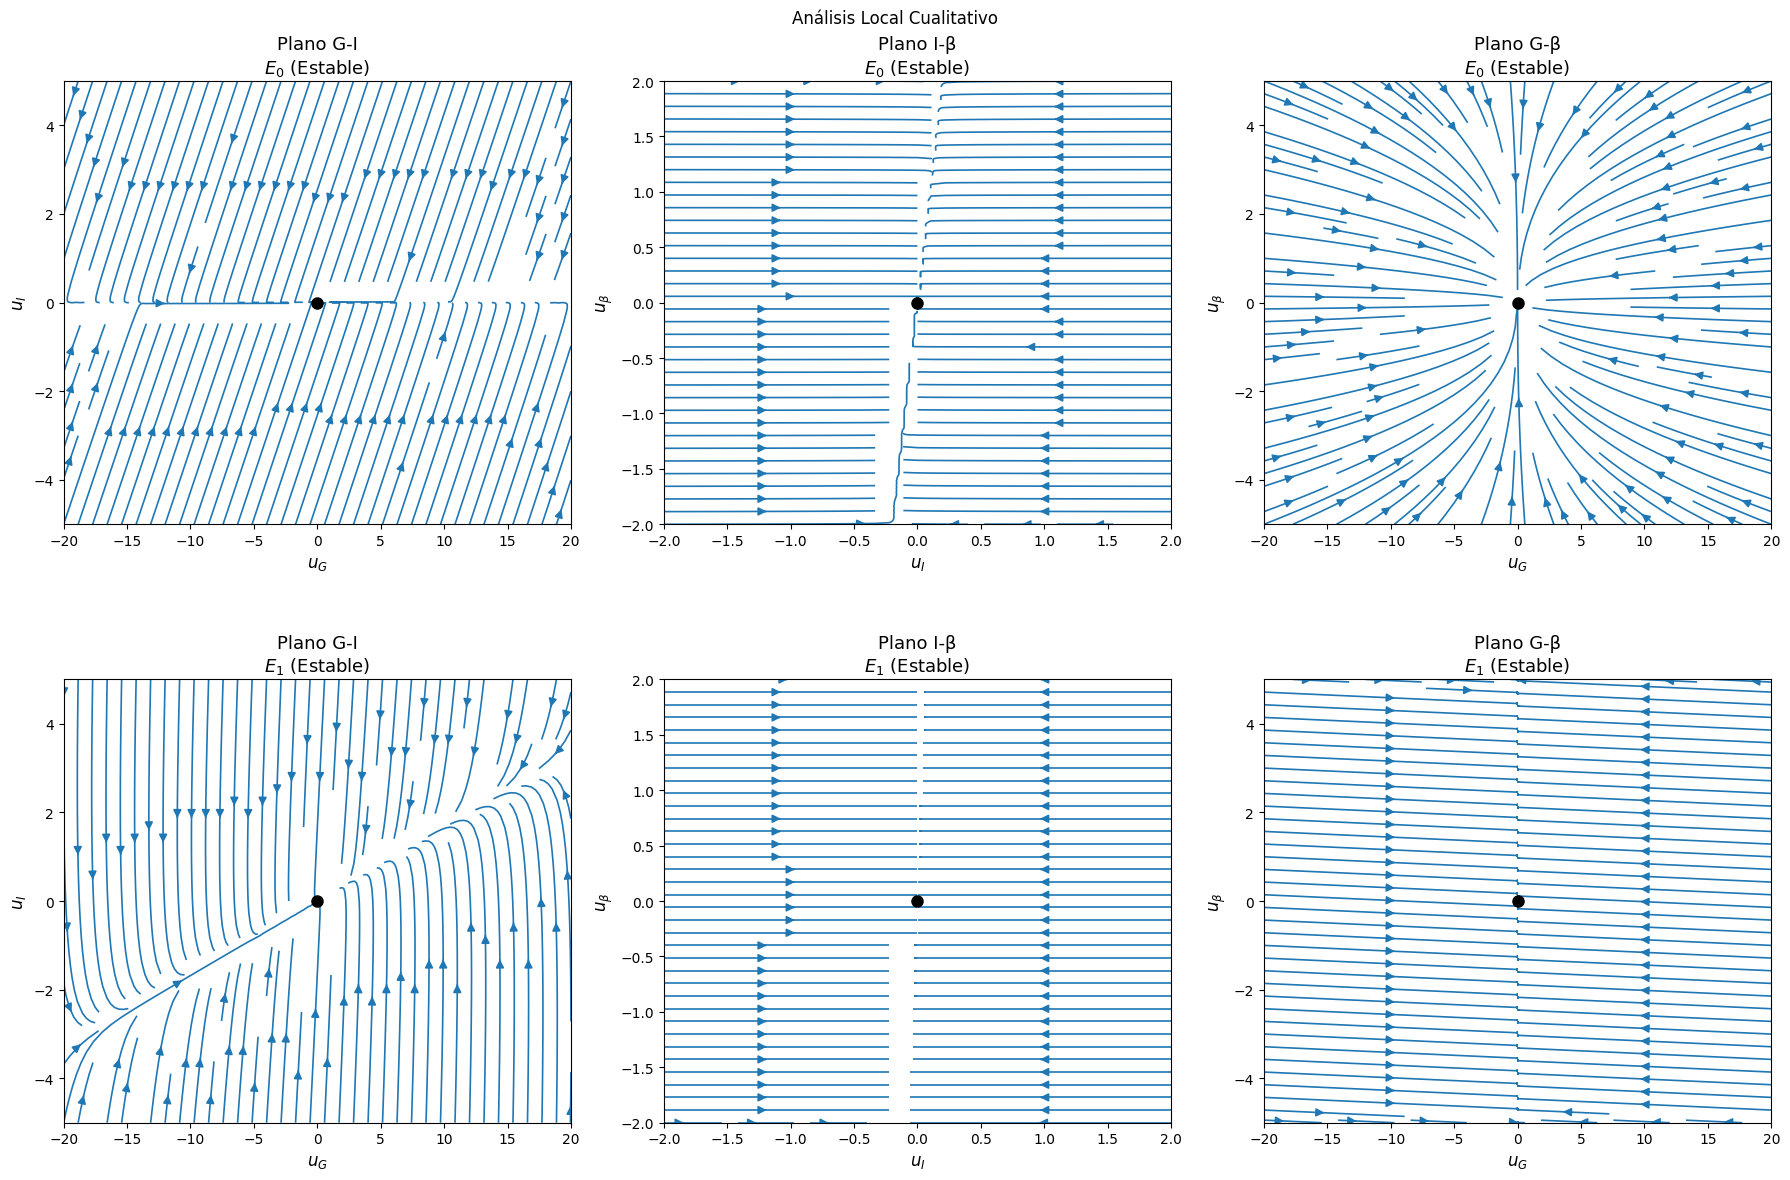

In [1]:
# ==================================================
# PARÁMETROS DEL SISTEMA
# ==================================================
E_GO = 1.44
S_I = 0.72
sigma = 43.2
alpha = 20000.0
rho = 0.41
k = 432.0
d0 = 0.06
r1 = 0.84e-3
r2 = 0.24e-5

# ==================================================
# PUNTOS DE EQUILIBRIO
# ==================================================
E1 = (100.0, 11.944, 358.673)
E0 = (697.22, 0.0, 0.0)

puntos = [E0, E1]
nombres_puntos = ['$E_0$ (Estable)', '$E_1$ (Estable)']

# ==================================================
# CÁLCULO DEL JACOBIANO EXACTO
# ==================================================
def jacobiano(G, I, beta):
    """Calcula la matriz Jacobiana 3x3 evaluada en el punto (G, I, beta)"""
    # fila 1
    J11 = -(E_GO + S_I * I)
    J12 = -S_I * G
    J13 = 0.0

    # fila 2
    denominador = (alpha + G**2)
    J21 = (2 * alpha * beta * sigma * G) / (denominador**2)
    J22 = -(rho + k)
    J23 = (sigma * G**2) / denominador

    # fila 3
    J31 = beta * (r1 - 2 * r2 * G)
    J32 = 0.0
    J33 = -d0 + r1 * G - r2 * G**2

    return np.array([
        [J11, J12, J13],
        [J21, J22, J23],
        [J31, J32, J33]
    ])

# ==================================================
# FUNCIÓN PARA RETRATO FASE
# ==================================================
def retrato_fase_azul(ax, A, xmin, xmax, ymin, ymax, titulo, xlabel, ylabel):
    """
      Hace los diagramas fase plano a partrir de una matriz 2x2.
    """

    # crear malla bidimiensional
    x = np.linspace(xmin, xmax, 200)
    y = np.linspace(ymin, ymax, 200)
    X, Y = np.meshgrid(x, y)

    # ecuaciones del subsistema local 2x2
    U = A[0,0]*X + A[0,1]*Y
    V = A[1,0]*X + A[1,1]*Y

    # === Normalizar vectores ===
    # Igualar las velocidades
    # existen variables con magnitudes mas altas
    magnitud = np.sqrt(U**2 + V**2)

    magnitud[magnitud == 0] = 1.0
    U_norm = U / magnitud
    V_norm = V / magnitud

    # graficar el comportamiento
    ax.streamplot(
        X, Y, U_norm, V_norm,
        density=1.2,
        linewidth=1.2,
        arrowsize=1.2
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(titulo, fontsize=13)
    ax.plot(0, 0, 'ko', markersize=8, zorder=5)
    ax.grid(False)

# ==================================================
# Generar subplots
# ==================================================
fig, axes = plt.subplots(len(puntos), 3, figsize=(18, 12))

# Límites para visualizar las dinámicas locales
# Se modificaron los límites para una mejor visualización
limites = {
    'GI': (-20, 20, -5, 5),
    'Ibeta': (-2, 2, -2, 2),
    'Gbeta': (-20, 20, -5, 5)
}

for i, punto in enumerate(puntos):
    G_eq, I_eq, beta_eq = punto
    # Obtener Jacobiano 3x3 completo
    J_3x3 = jacobiano(G_eq, I_eq, beta_eq)

    #  Extraer las submatrices 2x2 para cada plano
    # se fija una variable
    A_GI = J_3x3[np.ix_([0,1], [0,1])]      # Plano G-I
    A_Ibeta = J_3x3[np.ix_([1,2], [1,2])]   # Plano I-beta
    A_Gbeta = J_3x3[np.ix_([0,2], [0,2])]   # Plano G-beta

    nombre = nombres_puntos[i]

    #  Graficar cada columna de la fila 'i'
    retrato_fase_azul(axes[i, 0], A_GI, *limites['GI'], f'Plano G-I\n{nombre}', r'$u_G$', r'$u_I$')
    retrato_fase_azul(axes[i, 1], A_Ibeta, *limites['Ibeta'], f'Plano I-β\n{nombre}', r'$u_I$', r'$u_\beta$')
    retrato_fase_azul(axes[i, 2], A_Gbeta, *limites['Gbeta'], f'Plano G-β\n{nombre}', r'$u_G$', r'$u_\beta$')

plt.tight_layout()
# Ajustar el título principal
plt.subplots_adjust(top=0.92, hspace=0.35)
plt.suptitle('Análisis Local Cualitativo')

plt.show()

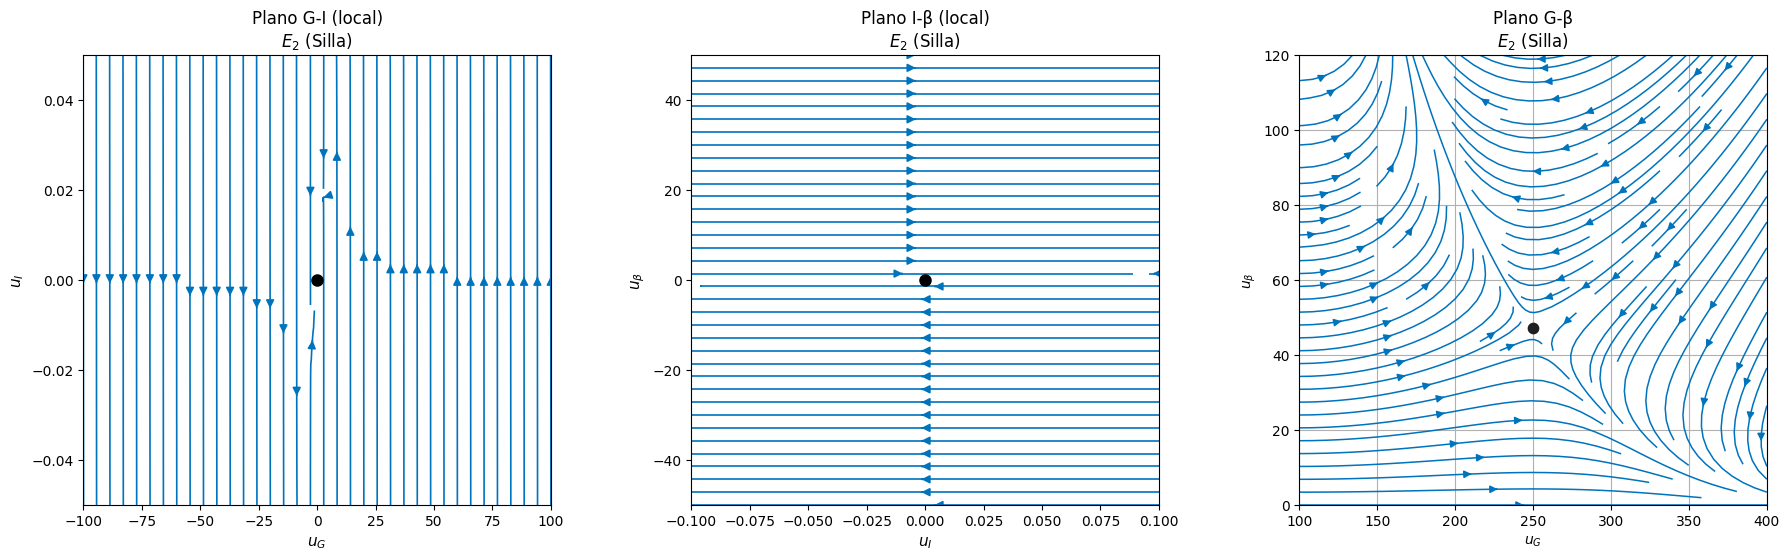

In [18]:
# ==================================================
# PARÁMETROS DEL SISTEMA
# ==================================================
R0    = 864.0
Ge    = 140.0
EGO   = 1.44
SI    = 0.72
sigma = 43.2
alpha = 20000.0
rho   = 0.41
k     = 432.0
d0    = 0.06
r1    = 0.00084
r2    = 0.0000024

# ==================================================
# Punto silla
# ==================================================
E2 = (250.0,  3.578,  47.271)

puntos        = [E2]
nombres_eq    = [r'$E_2$ (Silla)']

# Ventanas del plano G-β no lineal para cada equilibrio
configs_Gbeta = [
    {"Grange": (100, 400), "Brange": (0,   120),  "Bscale": 120},
]

# Ventanas locales para los planos linealizados
# se ajustaron los parámetros, hasta encontrar uno en dónde se viera el comportamiento
limites_local = {
    'GI':    (-100, 100, -0.05, 0.05),
    'Ibeta': (-0.1,  0.1, -50,   50),
}

N = 40   # resolución malla no lineal
NL = 200  # resolución malla linealizada

# ==================================================
# JACOBIANO 3 x 3
# ==================================================
def jacobiano(G, I, beta):
    denom = alpha + G**2
    J = np.array([
        [-(EGO + SI * I),                       -SI * G,                    0.0            ],
        [(2*alpha*beta*sigma*G) / denom**2,     -(rho + k),                 (sigma*G**2)/denom],
        [beta*(r1 - 2*r2*G),                     0.0,                       -d0+r1*G-r2*G**2],
    ])
    return J

# ==================================================
# PLANO G-β  NO LINEAL
# ==================================================
def plot_Gbeta_nonlinear(ax, G_eq, beta_eq, cfg, nombre):
    """
      Grafica el plano G-β no lineal. Se aume que dI/dt = 0, para que
      solo se muestre el plano G-β.
    """
    Gmin, Gmax = cfg["Grange"]
    Bmin, Bmax = cfg["Brange"]
    Bscale     = cfg["Bscale"]

    G_vals = np.linspace(Gmin, Gmax, N)
    B_vals = np.linspace(Bmin, Bmax, N)
    G, B   = np.meshgrid(G_vals, B_vals)
    # ecuaciones fijando I
    # calculo cuando dI/dt = 0
    I  = (B * sigma * G**2) / ((rho + k) * (alpha + G**2))
    # ecuaciones diferenciales del sistema
    dG = R0 + Ge - (EGO + SI * I) * G
    dB = (-d0 + r1 * G - r2 * G**2) * B

    ax.streamplot(
        G_vals, B_vals,
        dG, dB * Bscale,
        density=1.2,
        linewidth=1.1,
        arrowsize=1.1,
        color=[0.0, 0.45, 0.74],
    )
    ax.scatter(G_eq, beta_eq, s=55, color=[0.12, 0.12, 0.12], zorder=5)
    ax.set_title(f'Plano G-β\n{nombre}', fontsize=12)
    ax.set_xlabel(r'$u_G$')
    ax.set_ylabel(r'$u_\beta$')
    ax.set_xlim(Gmin, Gmax)
    ax.set_ylim(Bmin, Bmax)
    ax.grid(True)
    ax.set_facecolor('white')

# ==================================================
# PLANO LOCAL LINEALIZADO
# ==================================================
def plot_local(ax, A, xmin, xmax, ymin, ymax, titulo, xlabel, ylabel):
    x = np.linspace(xmin, xmax, NL)
    y = np.linspace(ymin, ymax, NL)
    X, Y = np.meshgrid(x, y)

    U = A[0, 0]*X + A[0, 1]*Y
    V = A[1, 0]*X + A[1, 1]*Y

    mag = np.sqrt(U**2 + V**2)
    mag[mag == 0] = 1.0
    U_n = U / mag
    V_n = V / mag

    ax.streamplot(
        X, Y, U_n, V_n,
        density=1.2,
        linewidth=1.2,
        arrowsize=1.2,
        color=[0.0, 0.45, 0.74],
    )
    ax.plot(0, 0, 'ko', markersize=8, zorder=5)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.grid(False)
    ax.set_facecolor('white')

# ==================================================
# FIGURA 3 × 3
# ==================================================
fig, axes = plt.subplots(len(puntos), 3, figsize=(18, 6), facecolor='white', squeeze=False)

for i, (punto, nombre, cfg) in enumerate(zip(puntos, nombres_eq, configs_Gbeta)):
    G_eq, I_eq, beta_eq = punto
    J = jacobiano(G_eq, I_eq, beta_eq)

    # Submatrices 2×2
    A_GI    = J[np.ix_([0, 1], [0, 1])]   # plano Glucosa-Insulina
    A_Ibeta = J[np.ix_([1, 2], [1, 2])]   # plano Insulina - Beta

    # G-I linealizado
    plot_local(
        axes[i, 0], A_GI,
        *limites_local['GI'],
        f'Plano G-I (local)\n{nombre}',
        r'$u_G$', r'$u_I$',
    )

    #  I-β linealizado
    plot_local(
        axes[i, 1], A_Ibeta,
        *limites_local['Ibeta'],
        f'Plano I-β (local)\n{nombre}',
        r'$u_I$', r'$u_\beta$',
    )

    # G-β no lineal
    plot_Gbeta_nonlinear(axes[i, 2], G_eq, beta_eq, cfg, nombre)

plt.tight_layout()
plt.subplots_adjust(top=0.85, hspace=0.40, wspace=0.30)
plt.show()